In [3]:
# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import quantus
import h5py
import os

2024-08-02 11:17:32.744384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-02 11:17:32.764148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-02 11:17:32.779864: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-02 11:17:32.784808: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-02 11:17:32.799232: I tensorflow/core/platform/cpu_feature_guar

In [4]:

# Cell 2: Load Model
model = tf.keras.models.load_model('results_50E/alexnet_audio_model.h5')


In [5]:
# Cell 3: Data Loading Function
def load_test_data(data_path, num_samples=8):
    X = []
    y = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.startswith('AlexNet') and file.endswith('.hdf5'):
                file_path = os.path.join(root, file)
                with h5py.File(file_path, 'r') as f:
                    X.append(f['data'][:])
                    y.append(f['label'][:, 0])
                if len(X) >= num_samples:
                    break
        if len(X) >= num_samples:
            break
    return np.concatenate(X, axis=0)[:num_samples], np.array(y)[:num_samples]


In [42]:
# Cell 4: Load and Preprocess Data
data_path = '/home/mqa887/tmp/audiomnist/AudioMNIST-master'
x_batch, y_batch = load_test_data(data_path)
x_batch = (x_batch - np.mean(x_batch)) / np.std(x_batch)  # Normalize

# Reshape the input to match the model's expected input shape
x_batch = np.transpose(x_batch, (0, 2, 3, 1))  # Change from (batch, 1, 227, 227) to (batch, 227, 227, 1)

print("Input shape:", x_batch.shape)
print("Label shape:", y_batch.shape)

Input shape: (8, 227, 227, 1)
Label shape: (8, 1)


In [50]:
# Generate Predictions
y_pred_raw = model(x_batch, training=False)
y_pred_classes = tf.argmax(y_pred_raw, axis=1)
print("Raw Predictions shape:", y_pred_raw.shape)
print("Raw Predictions:")
print(y_pred_raw)
print("\nPredicted Classes:")
print(y_pred_classes.numpy()) # Convert to numpy for easier viewing

Raw Predictions shape: (8, 10)
Raw Predictions:
tf.Tensor(
[[6.94267810e-10 5.01162783e-12 8.24192450e-11 2.40371334e-10
  2.29795558e-11 2.13910181e-10 9.99999881e-01 6.73523320e-11
  1.15206824e-07 3.11138421e-10]
 [2.10493359e-11 5.71516279e-10 4.47398104e-17 1.54164116e-12
  9.41045028e-16 5.26790452e-11 2.77842446e-13 3.50617035e-11
  7.12770517e-15 1.00000000e+00]
 [5.80529225e-09 5.69690201e-07 1.10293606e-11 7.89041632e-09
  6.86382340e-11 1.59530873e-06 7.39824702e-10 9.14235784e-07
  4.64189798e-10 9.99996901e-01]
 [1.75218032e-12 5.00470865e-09 7.43208663e-13 3.37089041e-08
  7.77822464e-08 9.99999642e-01 2.35154562e-09 8.56255600e-09
  9.44102130e-10 2.03434993e-07]
 [1.19863104e-13 8.84429769e-12 6.69266736e-15 1.02966219e-10
  5.66154723e-09 1.00000000e+00 9.12463827e-10 2.88748359e-10
  7.36541869e-11 1.45098855e-09]
 [6.56990391e-12 9.99999881e-01 4.64688346e-13 2.47947225e-13
  1.67965155e-07 6.65771258e-13 1.79673374e-14 4.27005335e-14
  8.65193927e-15 1.02126493e-11]

In [58]:
# Generate Integrated Gradients Explanations
a_batch_intgrad = []
for i, (x, y) in enumerate(zip(x_batch, y_pred_classes)):
    explanation = quantus.explain(
        model, 
        x[np.newaxis, ...],  # Add batch dimension
        y,  # Single class index
        method="IntegratedGradients"
    )
    a_batch_intgrad.append(explanation)

/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/functions/explanation_func.py:242: UserWarning: tf-explain library is being used for XAI attribution calculation. Consult with tf-explain documentation to find out the type of operations applied on the method output, i.e.  normalisation, taking the absolutevalue, etc.

  warnings.warn(


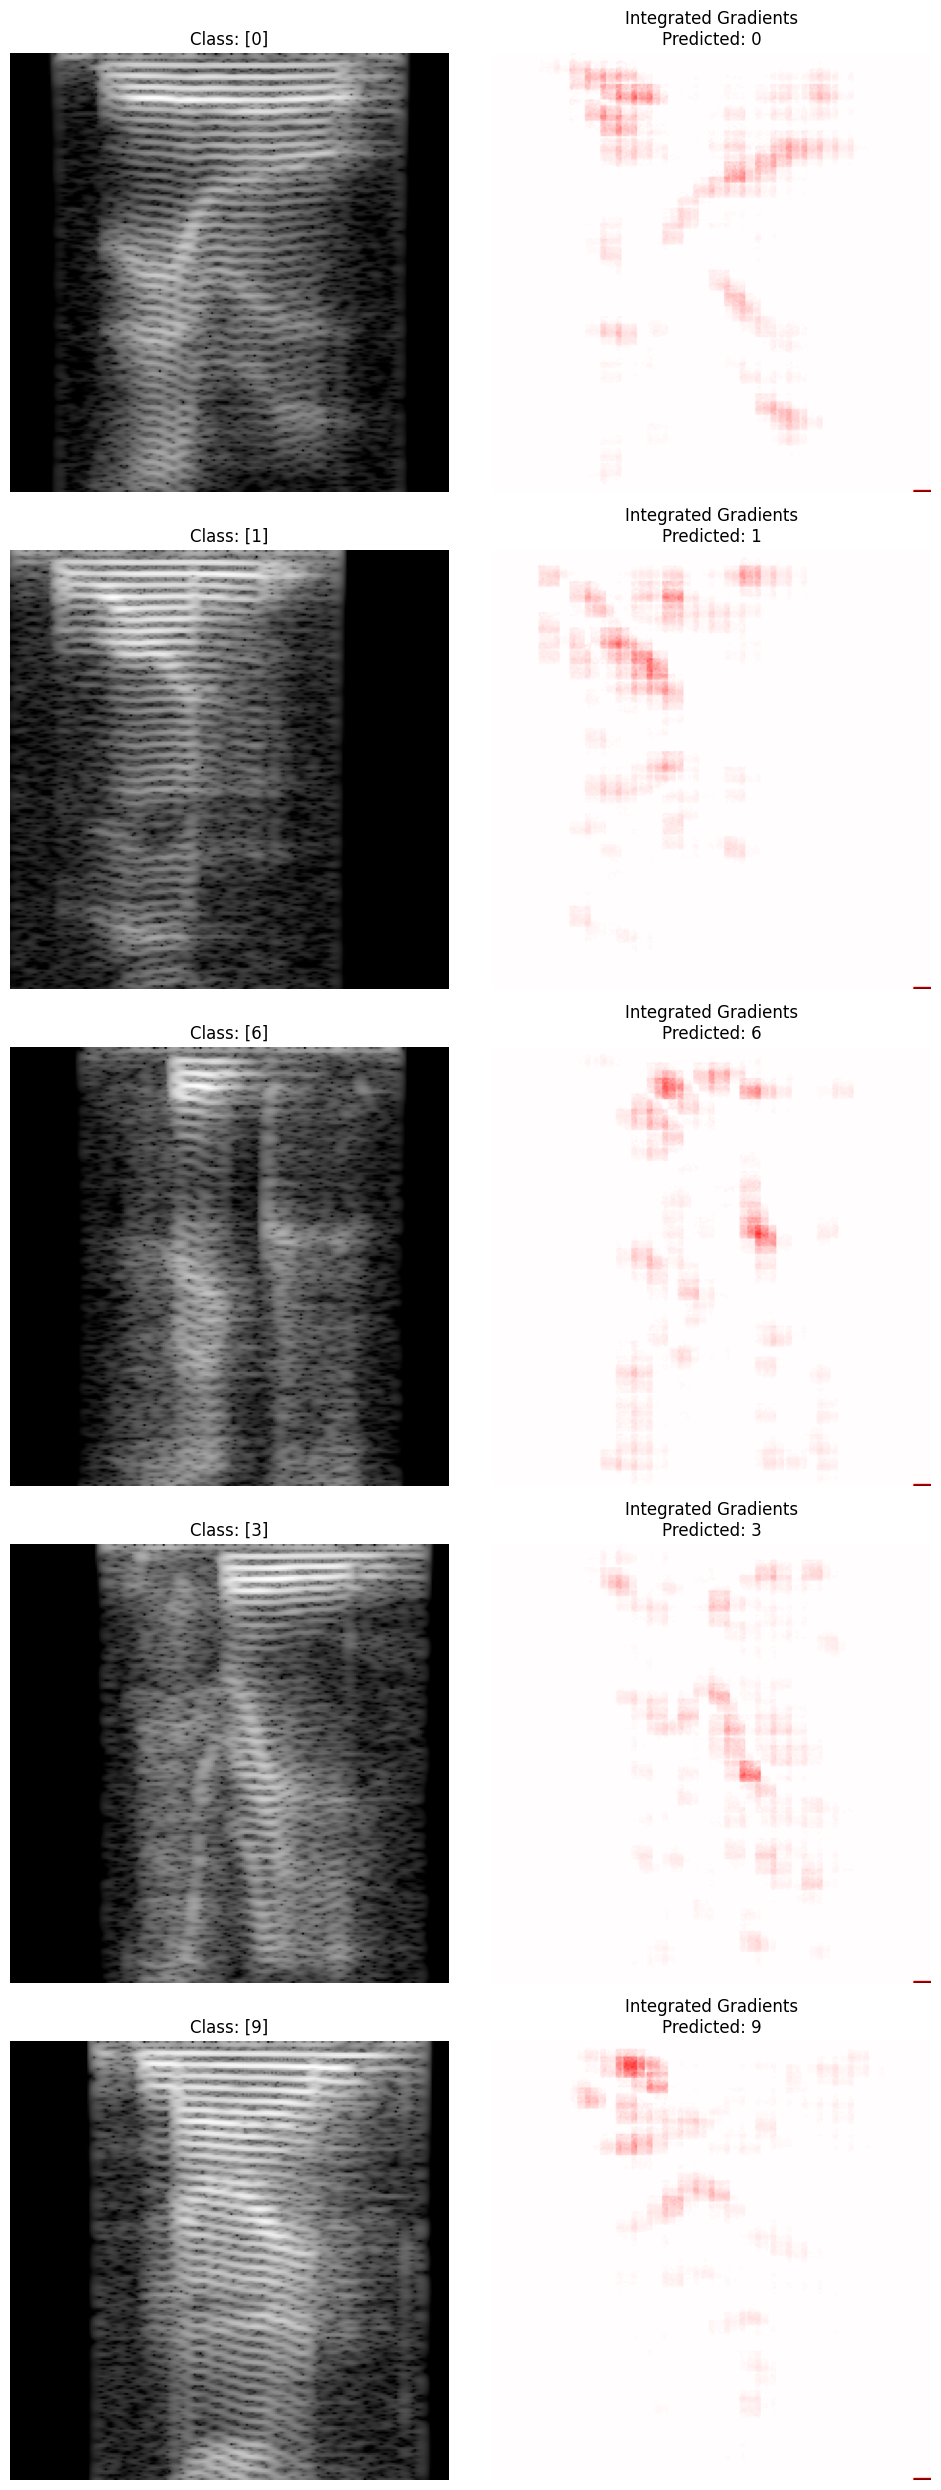

In [55]:
# Cell 7: Visualization Function
def visualize_explanations(x_batch, y_batch, y_pred, a_batch, num_samples=5):
    # Ensure num_samples does not exceed the batch size
    num_samples = min(num_samples, len(x_batch))
    
    # Generate random indices
    indices = np.random.choice(len(x_batch), num_samples, replace=False)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    
    for i, idx in enumerate(indices):
        axes[i, 0].imshow(x_batch[idx].squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Class: {y_batch[idx]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(a_batch[idx], cmap='seismic', clim=(-1, 1))
        axes[i, 1].set_title(f"Integrated Gradients\nPredicted: {y_pred_classes[idx]}")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage example
visualize_explanations(x_batch, y_batch, y_pred, a_batch_ig)


In [47]:
x_batch.shape

(8, 227, 227, 1)

In [48]:
# We will use the same non-default hyperparameters for all metrics.
init_kwargs = dict(
    disable_warnings=True,
    display_progressbar=True,
    abs=True,
    normalise=True,
    nr_samples=5,
    return_nan_when_prediction_changes=True,
)

call_kwargs = dict(
    model=model,
    x_batch=x_batch,
    y_batch=y_pred,
    a_batch=a_batch_ig,
    explain_func=quantus.explain,
    explain_func_kwargs={"method": "IntegratedGradients"},
    channel_first=True,
)

In [49]:
# Instantiate metric.
max_sen = quantus.MaxSensitivity(**init_kwargs)
# Evaluate metric.
scores_intgrad_maxs = max_sen(**call_kwargs)

  0%|          | 0/1.0 [00:00<?, ?it/s]

ValueError: The layer sequential has never been called and thus has no defined input.

In [8]:
# Cell 9: Set up Quantus Metrics
metrics = [
    quantus.MaxSensitivity(),
    quantus.AvgSensitivity(),
    quantus.RelativeInputStability(),
    quantus.RelativeOutputStability(),
    quantus.RelativeRepresentationStability(),
]



In [14]:
import quantus

# Define an explanation function
def explain_func(model, inputs, targets, **kwargs):
    with tf.GradientTape() as tape:
        inputs = tf.convert_to_tensor(inputs, dtype=tf.float32)
        tape.watch(inputs)
        predictions = model(inputs)
        loss = tf.keras.losses.sparse_categorical_crossentropy(targets, predictions)
    gradients = tape.gradient(loss, inputs)
    return gradients.numpy()

# Cell 10: Evaluate Metrics
results = {}
metrics = [
    quantus.MaxSensitivity(nr_samples=10),
    quantus.AvgSensitivity(nr_samples=10),
    quantus.RelativeInputStability(nr_samples=10),
    quantus.RelativeOutputStability(nr_samples=10),
    quantus.RelativeRepresentationStability(nr_samples=10),
]

for metric in metrics:
    print(f"\nEvaluating {metric.__class__.__name__}:")
    print("x_batch shape:", x_batch.shape)
    print("y_pred shape:", y_pred.shape)
    print("a_batch_ig shape:", a_batch_ig.shape)
    
    # Add channel dimension to a_batch_ig if it's missing
    if a_batch_ig.ndim == 3:
        a_batch_ig = np.expand_dims(a_batch_ig, axis=-1)
    print("Updated a_batch_ig shape:", a_batch_ig.shape)
    
    try:
        # Get default parameters
        params = metric.get_params() if callable(getattr(metric, 'get_params', None)) else {}
        
        # Add explain_func to params
        params['explain_func'] = explain_func
        
        # Adjust parameters based on the metric
        if isinstance(metric, quantus.RelativeInputStability):
            params['layer_names'] = [model.layers[-1].name]  # Use the last layer
        elif isinstance(metric, quantus.RelativeRepresentationStability):
            params['layer_names'] = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
        
        # Ensure the model has been called at least once
        _ = model(x_batch)
        
        score = metric(
            model=model,
            x_batch=x_batch,
            y_batch=y_pred,
            a_batch=a_batch_ig,
            **params
        )
        results[metric.__class__.__name__] = score
        print(f"Successfully evaluated {metric.__class__.__name__}")
    except Exception as e:
        print(f"Error evaluating {metric.__class__.__name__}: {str(e)}")
    
    print(f"Parameters used for {metric.__class__.__name__}:")
    print(params)
    print()

# Print results
for metric_name, score in results.items():
    print(f"{metric_name}: {score}")


Evaluating MaxSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227)
Updated a_batch_ig shape: (8, 227, 227, 1)
Successfully evaluated MaxSensitivity
Parameters used for MaxSensitivity:
{'explain_func': <function explain_func at 0x7fde6049ede0>}


Evaluating AvgSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227, 1)
Updated a_batch_ig shape: (8, 227, 227, 1)
Successfully evaluated AvgSensitivity
Parameters used for AvgSensitivity:
{'explain_func': <function explain_func at 0x7fde6049ede0>}


Evaluating RelativeInputStability:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227, 1)
Updated a_batch_ig shape: (8, 227, 227, 1)
Error evaluating RelativeInputStability: The layer sequential has never been called and thus has no defined input.
Parameters used for RelativeInputStability:
{'explain_func': <function explain_func at 0x7fde6049ede0>, 'layer_names': ['dense_2']}


Evalu

/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/helpers/model/tf_model.py:289: UserWarning: quantus.TensorFlowModel.get_hidden_layers_representations(...) received `layer_names`=None and `layer_indices`=None. This will force creation of tensorflow.keras.Model with outputs of each layer from original model. This can be very computationally expensive.
  warn(


In [18]:
# Instantiate metric.
max_sen = quantus.MaxSensitivity(**init_kwargs)
# Evaluate metric.
scores_intgrad_maxs = max_sen(**call_kwargs)

ValueError: The layer sequential has never been called and thus has no defined input.

In [15]:

# Cell 11: Print Results
print("Quantus Analysis Results:")
for metric, score in results.items():
    print(f"{metric}: {np.mean(score):.4f} ± {np.std(score):.4f}")


Quantus Analysis Results:
MaxSensitivity: 1.0000 ± 0.0000
AvgSensitivity: 1.0000 ± 0.0000


In [16]:

# Cell 12: Create and Display Results DataFrame
results_df = pd.DataFrame({metric: score for metric, score in results.items()})
results_df.describe()

,MaxSensitivity,AvgSensitivity
count,8.000000e+00,8.000000e+00
mean,1.000000e+00,1.000000e+00
std,9.214834e-08,6.972931e-08
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00


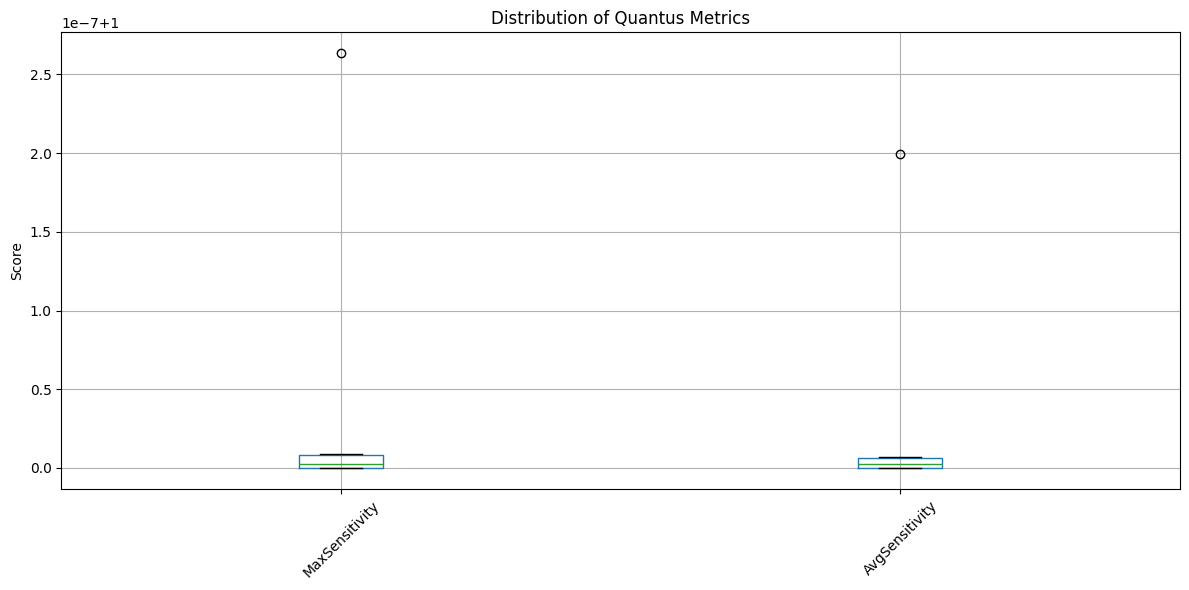

In [17]:
# Cell 13: Visualize Metric Distributions
plt.figure(figsize=(12, 6))
results_df.boxplot()
plt.title("Distribution of Quantus Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Assuming x_batch is your input data
_ = model(x_batch)

Error discussing GradCAM 

https://github.com/understandable-machine-intelligence-lab/Quantus/issues/122

In [21]:
# Cell 14: Generate LIME Explanations
a_batch_lime = quantus.explain(model, x_batch, y_pred, method="LIME")

# Cell 15: Visualize LIME Explanations
visualize_explanations(x_batch, y_pred, a_batch_lime, num_samples=3)

KeyError: "To use the 'quantus.explain' method with tf-explain as a supporting library, specify a XAI method that is supported ['VanillaGradients', 'IntegratedGradients', 'GradientsInput', 'OcclusionSensitivity', 'GradCAM', 'SmoothGrad']."

In [22]:
# Cell 16: Function to Compare Explanations
def compare_explanations(x_batch, y_pred, a_batch_ig, a_batch_gradcam, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(x_batch[i].squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Predicted: {y_pred[i]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(a_batch_ig[i], cmap='seismic', clim=(-1, 1))
        axes[i, 1].set_title("Integrated Gradients")
        axes[i, 1].axis('off')
        axes[i, 2].imshow(a_batch_gradcam[i], cmap='jet', clim=(0, 1))
        axes[i, 2].set_title("Grad-CAM")
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()


# Cell 17: Compare Integrated Gradients and Grad-CAM
compare_explanations(x_batch, y_pred, a_batch_ig, a_batch_gradcam)

NameError: name 'a_batch_gradcam' is not defined

In [ ]:
# Add this before the metrics evaluation loop
print("Model summary:")
model.summary()

print("\nInput shapes:")
print("x_batch shape:", x_batch.shape)
print("y_pred shape:", y_pred.shape)
print("a_batch_ig shape:", a_batch_ig.shape)

# Add this inside the loop, just before calling the metric
print(f"\nEvaluating {metric.__class__.__name__}:")
print("x_batch shape:", x_batch.shape)
print("y_pred shape:", y_pred.shape)
print("a_batch_ig shape:", a_batch_ig.shape)

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        11,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,222,027 (54.25 MB)

 Trainable params: 14,222,026 (54.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1 (8.00 B)


Input shapes:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227)

Evaluating MaxSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227)
